# Primer Examen Parcial - SIS 420 Inteligencia Artificial I

Estudiante: Arduz Espada Juan Sebastian

Dataset: Speaker Recognition Dataset (Kaggle): https://www.kaggle.com/datasets/kongaevans/speaker-recognition-dataset

El objetivo es clasificar quien esta hablando en un audio de 1 segundo. Son 5 personas: Benjamin Netanyahu, Jens Stoltenberg, Julia Gillard, Margaret Thatcher y Nelson Mandela. Para eso armo una red neuronal en PyTorch y la comparo con el modelo lineal que usamos en los laboratorios.

## 1. Librerias y descarga del dataset

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
import kagglehub
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio, display

SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
os.makedirs('pesos', exist_ok=True)
dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| librosa', librosa.__version__, '|', dispositivo)

PyTorch 2.14.0+cpu | librosa 1.0.0 | cpu


In [2]:
ruta = kagglehub.dataset_download('kongaevans/speaker-recognition-dataset')
CARPETA = os.path.join(ruta, '16000_pcm_speeches')
print(sorted(os.listdir(CARPETA)))

['Benjamin_Netanyau', 'Jens_Stoltenberg', 'Julia_Gillard', 'Magaret_Tarcher', 'Nelson_Mandela', '_background_noise_', 'other', 'tf_Wav_reader.py']


## 2. Exploracion de los audios

In [3]:
HABLANTES = ['Benjamin_Netanyau', 'Jens_Stoltenberg', 'Julia_Gillard', 'Magaret_Tarcher', 'Nelson_Mandela']
NOMBRES = ['Benjamin Netanyahu', 'Jens Stoltenberg', 'Julia Gillard', 'Margaret Thatcher', 'Nelson Mandela']

filas = []
for hablante in HABLANTES:
    todos = [f for f in os.listdir(os.path.join(CARPETA, hablante)) if f.endswith('.wav')]
    numerados = set(f for f in todos if f[:-4].isdigit())
    formatos = set()
    for f in numerados:
        info = sf.info(os.path.join(CARPETA, hablante, f))
        formatos.add((info.samplerate, info.frames, info.channels))
    filas.append({'hablante': hablante, 'archivos wav': len(todos), 'numerados': len(numerados),
                  'sin numero': [f for f in todos if f not in numerados],
                  'formato (Hz, muestras, canales)': sorted(formatos)})
pd.DataFrame(filas)

,hablante,archivos wav,numerados,sin numero,"formato (Hz, muestras, canales)"
0,Benjamin_Netanyau,1500,1500,[],"[(16000, 16000, 1)]"
1,Jens_Stoltenberg,1500,1500,[],"[(16000, 16000, 1)]"
2,Julia_Gillard,1501,1500,[new.wav],"[(16000, 16000, 1)]"
3,Magaret_Tarcher,1500,1500,[],"[(16000, 16000, 1)]"
4,Nelson_Mandela,1500,1500,[],"[(16000, 16000, 1)]"


In [4]:
NOMBRES_RUIDO = ['aplausos', 'lavar platos', 'gato', 'grifo', 'bicicleta', 'ruido rosa']
ruidos = []
for carpeta in ['_background_noise_', 'other']:
    for f in sorted(os.listdir(os.path.join(CARPETA, carpeta))):
        senal, _ = librosa.load(os.path.join(CARPETA, carpeta, f), sr=16000)
        ruidos.append(senal)
for nombre, senal in zip(NOMBRES_RUIDO, ruidos):
    print(f'{nombre:14s} {len(senal) / 16000:6.1f} segundos')

aplausos         16.3 segundos
lavar platos     95.2 segundos
gato             61.8 segundos
grifo            61.2 segundos
bicicleta        61.3 segundos
ruido rosa       60.0 segundos


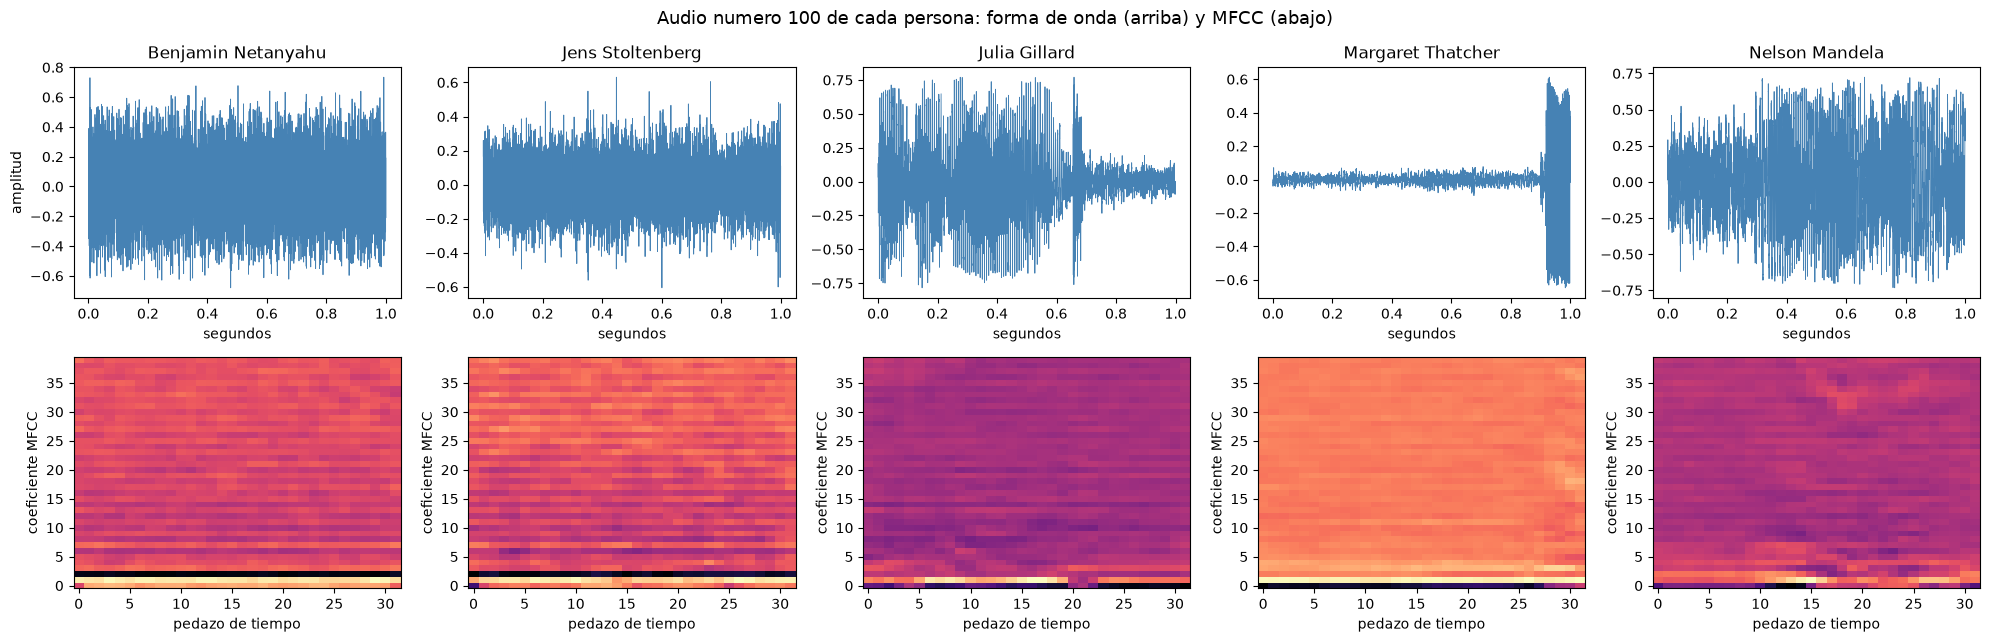

Audio 100 de Nelson Mandela:


In [5]:
fig, ejes = plt.subplots(2, 5, figsize=(20, 6.5))
for k, hablante in enumerate(HABLANTES):
    senal, sr = librosa.load(os.path.join(CARPETA, hablante, '100.wav'), sr=16000)
    ejes[0, k].plot(np.arange(len(senal)) / sr, senal, color='steelblue', linewidth=0.6)
    ejes[0, k].set_title(NOMBRES[k])
    ejes[0, k].set_xlabel('segundos')
    mfcc = librosa.feature.mfcc(y=senal, sr=sr, n_mfcc=40)
    ejes[1, k].imshow(mfcc, aspect='auto', origin='lower', cmap='magma')
    ejes[1, k].set_xlabel('pedazo de tiempo')
    ejes[1, k].set_ylabel('coeficiente MFCC')
ejes[0, 0].set_ylabel('amplitud')
plt.suptitle('Audio numero 100 de cada persona: forma de onda (arriba) y MFCC (abajo)', fontsize=13)
plt.tight_layout()
plt.show()

print('Audio 100 de Nelson Mandela:')
display(Audio(os.path.join(CARPETA, 'Nelson_Mandela', '100.wav')))

Cada persona tiene 1500 audios numerados del 0 al 1499, todos de 1 segundo, a 16000 Hz y en mono, asi que no hay que recortar ni convertir nada. Julia Gillard tiene un archivo extra (new.wav) que no sigue la numeracion; lo saco para que las 5 clases queden con 1500 audios cada una, o sea que el dataset esta balanceado.

El dataset tambien trae 6 grabaciones de ruido (aplausos, lavar platos, un gato, un grifo, una bicicleta y ruido rosa). Las uso mas adelante.

En las graficas se ve que la forma de onda de cada persona es bastante distinta, pero con solo mirarla es dificil decir quien habla. Por eso trabajo con los MFCC.

## 3. Caracteristicas del audio (MFCC) y audio con ruido

Un audio de 1 segundo son 16000 numeros. En vez de meter todo eso a la red saco los MFCC, que son 40 numeros por cada pedacito del audio y describen el timbre de la voz (como suena cada persona). El audio queda dividido en 32 pedacitos, entonces a cada coeficiente le saco el promedio y la desviacion estandar: al final cada audio queda como 80 numeros.

Para que el problema se parezca mas a la vida real, tambien armo una version con ruido: a cada audio le sumo un pedazo al azar de alguno de los 6 ruidos, con un volumen que va de la mitad a 1.5 veces el volumen de la voz.

In [6]:
N_MFCC = 40
rng = np.random.RandomState(SEMILLA)


def caracteristicas(senal):
    mfcc = librosa.feature.mfcc(y=senal, sr=16000, n_mfcc=N_MFCC)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])


def mezclar_ruido(senal):
    r = rng.randint(len(ruidos))
    inicio = rng.randint(len(ruidos[r]) - len(senal))
    pedazo = ruidos[r][inicio:inicio + len(senal)]
    nivel = rng.uniform(0.5, 1.5)
    volumen_voz = np.sqrt(np.mean(senal ** 2))
    volumen_ruido = np.sqrt(np.mean(pedazo ** 2)) + 1e-8
    return senal + pedazo * nivel * volumen_voz / volumen_ruido, r


X_limpio, X_ruido, etiquetas, numero, tipo_ruido = [], [], [], [], []
inicio_t = time.time()
for k, hablante in enumerate(HABLANTES):
    archivos = sorted([f for f in os.listdir(os.path.join(CARPETA, hablante)) if f[:-4].isdigit()],
                      key=lambda f: int(f[:-4]))
    for f in archivos:
        senal, _ = librosa.load(os.path.join(CARPETA, hablante, f), sr=16000)
        con_ruido, r = mezclar_ruido(senal)
        X_limpio.append(caracteristicas(senal))
        X_ruido.append(caracteristicas(con_ruido))
        etiquetas.append(k)
        numero.append(int(f[:-4]))
        tipo_ruido.append(r)
    print(f'{NOMBRES[k]:20s} {len(archivos)} audios   ({time.time() - inicio_t:.0f} s)')

X_limpio = np.array(X_limpio)
X_ruido = np.array(X_ruido)
y = np.array(etiquetas)
numero = np.array(numero)
tipo_ruido = np.array(tipo_ruido)
print('Sin ruido:', X_limpio.shape, '  Con ruido:', X_ruido.shape, '  Audios por clase:', np.bincount(y))

Benjamin Netanyahu   1500 audios   (14 s)


Jens Stoltenberg     1500 audios   (28 s)


Julia Gillard        1500 audios   (42 s)


Margaret Thatcher    1500 audios   (56 s)


Nelson Mandela       1500 audios   (69 s)
Sin ruido: (7500, 80)   Con ruido: (7500, 80)   Audios por clase: [1500 1500 1500 1500 1500]


El mismo audio de Nelson Mandela con ruido de lavar platos:


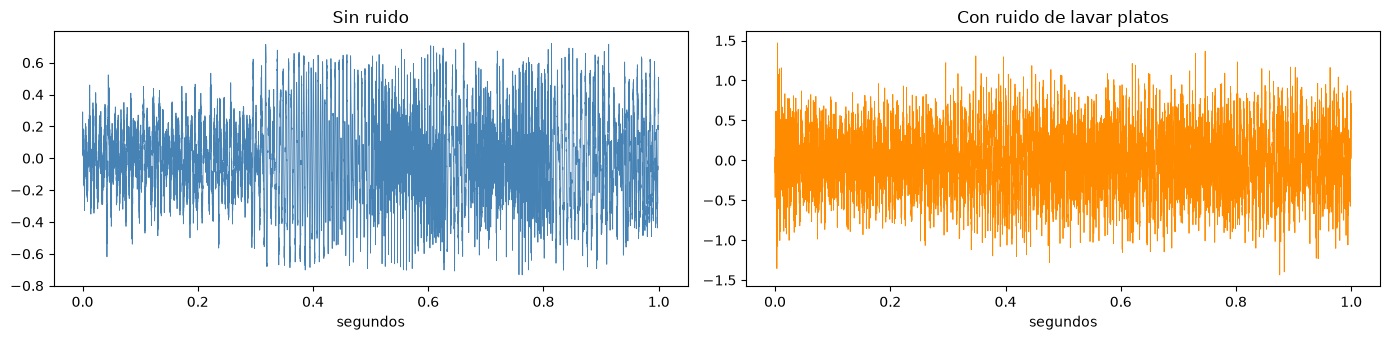

In [7]:
senal, _ = librosa.load(os.path.join(CARPETA, 'Nelson_Mandela', '100.wav'), sr=16000)
ejemplo, r = mezclar_ruido(senal)
print('El mismo audio de Nelson Mandela con ruido de', NOMBRES_RUIDO[r] + ':')
display(Audio(ejemplo, rate=16000))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.5))
ax1.plot(np.arange(len(senal)) / 16000, senal, color='steelblue', linewidth=0.6)
ax1.set_title('Sin ruido')
ax2.plot(np.arange(len(ejemplo)) / 16000, ejemplo, color='darkorange', linewidth=0.6)
ax2.set_title('Con ruido de ' + NOMBRES_RUIDO[r])
for ax in (ax1, ax2):
    ax.set_xlabel('segundos')
plt.tight_layout()
plt.show()

## 4. Division en entrenamiento, validacion y prueba

Uso tres conjuntos como dice el material de clase: entrenamiento (70%) para ajustar los pesos, validacion (15%) para elegir la configuracion de la red y la mejor epoca, y prueba (15%) que solo uso al final para medir el resultado.

La division es secuencial por persona: los audios 0 a 1049 van a entrenamiento, del 1050 al 1274 a validacion y del 1275 al 1499 a prueba. Lo hice asi porque los audios son pedazos seguidos de los mismos discursos; si los mezclo al azar, un pedazo de prueba puede estar justo al lado de uno de entrenamiento y el resultado sale mejor de lo que es. Asi el modelo se prueba con partes del discurso que nunca escucho.

Despues normalizo con z-score usando la media y la desviacion solo del entrenamiento.

In [8]:
idx_train, idx_val, idx_test = [], [], []
for k in range(len(HABLANTES)):
    indices = np.where(y == k)[0]
    indices = indices[np.argsort(numero[indices])]
    a, b = int(0.70 * len(indices)), int(0.85 * len(indices))
    idx_train += list(indices[:a])
    idx_val += list(indices[a:b])
    idx_test += list(indices[b:])
idx_train, idx_val, idx_test = np.array(idx_train), np.array(idx_val), np.array(idx_test)
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]


def normalizar(X):
    mu = X[idx_train].mean(axis=0)
    sigma = X[idx_train].std(axis=0)
    sigma[sigma == 0] = 1
    return (X[idx_train] - mu) / sigma, (X[idx_val] - mu) / sigma, (X[idx_test] - mu) / sigma, mu, sigma


print('Entrenamiento:', len(idx_train), '  Validacion:', len(idx_val), '  Prueba:', len(idx_test))
print('Por clase en prueba:', np.bincount(y_test))

Entrenamiento: 5250   Validacion: 1125   Prueba: 1125
Por clase en prueba: [225 225 225 225 225]


## 5. Objetos de PyTorch

Igual que en el lab 06:
- DatasetAudio (hereda de Dataset) guarda las caracteristicas y las etiquetas, y el DataLoader arma los lotes de 64 audios mezclados en cada epoca.
- RedNeuronal (hereda de nn.Module) arma la red con las capas ocultas que le pida. Cada capa oculta es un nn.Linear seguido de ReLU, que es lo que le permite a la red aprender fronteras que no son rectas. Si le paso cero capas ocultas queda un solo nn.Linear, que es la regresion logistica multiclase de los labs.
- El costo es CrossEntropyLoss, que aplica softmax a las 5 salidas para convertirlas en probabilidades.
- En cada lote van los cinco pasos: zero_grad, forward, costo, backward (los gradientes se calculan solos) y step.
- Despues de cada epoca mido la exactitud en validacion y guardo un checkpoint cada vez que mejora. Al final la red se queda con los pesos de la mejor epoca y no con los de la ultima; asi evito quedarme con una red sobreajustada.

In [9]:
class DatasetAudio(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


class RedNeuronal(nn.Module):
    def __init__(self, entradas, capas_ocultas, salidas, dropout=0.0):
        super().__init__()
        partes = []
        anterior = entradas
        for neuronas in capas_ocultas:
            partes.append(nn.Linear(anterior, neuronas))
            partes.append(nn.ReLU())
            if dropout > 0:
                partes.append(nn.Dropout(dropout))
            anterior = neuronas
        partes.append(nn.Linear(anterior, salidas))
        self.red = nn.Sequential(*partes)

    def forward(self, x):
        return self.red(x)


def predecir(modelo, X):
    modelo.eval()
    with torch.no_grad():
        salida = modelo(torch.tensor(X, dtype=torch.float32).to(dispositivo)).cpu()
    return salida.argmax(dim=1).numpy(), torch.softmax(salida, dim=1).numpy()


def entrenar(capas, datos, optimizador='adam', lr=0.001, dropout=0.0, epocas=80, lote=64, nombre=None, mostrar=False):
    X_tr, y_tr, X_va, y_va = datos
    torch.manual_seed(SEMILLA)
    modelo = RedNeuronal(X_tr.shape[1], capas, 5, dropout).to(dispositivo)
    if optimizador == 'adam':
        opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    else:
        opt = torch.optim.SGD(modelo.parameters(), lr=lr)
    criterio = nn.CrossEntropyLoss()
    cargador = DataLoader(DatasetAudio(X_tr, y_tr), batch_size=lote, shuffle=True)
    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(dispositivo)
    y_va_t = torch.tensor(y_va, dtype=torch.long).to(dispositivo)
    historial = {'costo_train': [], 'costo_val': [], 'exac_train': [], 'exac_val': []}
    mejor_exac, mejor_epoca, mejor_estado = -1.0, 0, None
    for epoca in range(1, epocas + 1):
        modelo.train()
        suma, aciertos, total = 0.0, 0, 0
        for xb, yb in cargador:
            xb, yb = xb.to(dispositivo), yb.to(dispositivo)
            opt.zero_grad()
            salida = modelo(xb)
            costo = criterio(salida, yb)
            costo.backward()
            opt.step()
            suma += costo.item() * len(xb)
            aciertos += (salida.argmax(dim=1) == yb).sum().item()
            total += len(xb)
        modelo.eval()
        with torch.no_grad():
            salida_va = modelo(X_va_t)
            costo_va = criterio(salida_va, y_va_t).item()
            exac_va = (salida_va.argmax(dim=1) == y_va_t).float().mean().item()
        historial['costo_train'].append(suma / total)
        historial['costo_val'].append(costo_va)
        historial['exac_train'].append(aciertos / total)
        historial['exac_val'].append(exac_va)
        if exac_va > mejor_exac:
            mejor_exac, mejor_epoca = exac_va, epoca
            mejor_estado = {k: v.detach().clone() for k, v in modelo.state_dict().items()}
            if nombre is not None:
                torch.save({'epoca': epoca, 'estado_modelo': modelo.state_dict(),
                            'estado_optimizador': opt.state_dict(), 'exac_val': exac_va},
                           os.path.join('pesos', nombre + '.pt'))
        if mostrar and (epoca == 1 or epoca % 10 == 0):
            print(f'Epoca {epoca:3d}  costo train {suma / total:.4f}  costo val {costo_va:.4f}  '
                  f'exactitud train {aciertos / total:.4f}  exactitud val {exac_va:.4f}')
    modelo.load_state_dict(mejor_estado)
    return modelo, historial, mejor_epoca, mejor_exac


print(RedNeuronal(80, [], 5))
print(RedNeuronal(80, [128, 64], 5, dropout=0.2))

RedNeuronal(
  (red): Sequential(
    (0): Linear(in_features=80, out_features=5, bias=True)
  )
)
RedNeuronal(
  (red): Sequential(
    (0): Linear(in_features=80, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=5, bias=True)
  )
)


## 6. Primera prueba con el audio sin ruido

In [10]:
Xl_tr, Xl_va, Xl_te, mu_l, sigma_l = normalizar(X_limpio)
datos_limpio = (Xl_tr, y_train, Xl_va, y_val)

filas = []
for nombre, capas in [('Lineal (como en los labs)', []), ('Red neuronal, 1 capa oculta de 128', [128])]:
    modelo, historial, epoca, exac_val = entrenar(capas, datos_limpio, epocas=60)
    pred, _ = predecir(modelo, Xl_te)
    filas.append({'modelo': nombre, 'exactitud validacion': exac_val, 'exactitud prueba': np.mean(pred == y_test)})
pd.DataFrame(filas).set_index('modelo').round(4)

,exactitud validacion,exactitud prueba
modelo,,
Lineal (como en los labs),1.0000,0.9947
"Red neuronal, 1 capa oculta de 128",0.9991,0.9982


Con el audio limpio los dos modelos casi no se equivocan: el lineal acierta el 99.5% en prueba y la red el 99.8%. O sea que con audio limpio las voces se distinguen muy facil con los MFCC y ni siquiera hace falta una red neuronal.

Por eso el resto del trabajo lo hago con el audio con ruido, que es un caso mas real y donde se nota si la red neuronal sirve o no.

## 7. Modelo lineal con el audio con ruido

Primero pruebo el modelo de los labs (un solo nn.Linear con softmax) para tener con que comparar la red neuronal.

In [11]:
Xr_tr, Xr_va, Xr_te, mu_r, sigma_r = normalizar(X_ruido)
datos_ruido = (Xr_tr, y_train, Xr_va, y_val)

modelo_lineal, hist_lineal, ep_lineal, val_lineal = entrenar([], datos_ruido, epocas=80, nombre='lineal')
pred_tr_lin, _ = predecir(modelo_lineal, Xr_tr)
pred_lineal, _ = predecir(modelo_lineal, Xr_te)
print(f'Mejor epoca: {ep_lineal}')
print(f'Exactitud entrenamiento: {np.mean(pred_tr_lin == y_train):.4f}')
print(f'Exactitud validacion:    {val_lineal:.4f}')
print(f'Exactitud prueba:        {np.mean(pred_lineal == y_test):.4f}')

Mejor epoca: 70
Exactitud entrenamiento: 0.8844
Exactitud validacion:    0.8684
Exactitud prueba:        0.8578


Con ruido el modelo lineal baja bastante: 85.8% en prueba, cuando sin ruido tenia 99.5%. En entrenamiento tiene 88.4%, casi lo mismo, entonces no es sobreajuste. El problema es que el modelo lineal solo puede separar las clases con fronteras rectas y con el ruido eso ya no alcanza.

## 8. Red neuronal: eleccion de la configuracion

Pruebo varias configuraciones y elijo la que tiene mejor exactitud en validacion (la prueba no la toco para esto):
- Cantidad de capas ocultas y neuronas: 1 capa de 128 o de 256, y 2 capas de 128-64 o de 256-128.
- Optimizador y tasa de aprendizaje: SGD con 0.01 y 0.1, y Adam con 0.0001, 0.001 y 0.01.
- Dropout, que apaga al azar una parte de las neuronas en cada paso del entrenamiento para que la red no se aprenda de memoria los datos de entrenamiento: 0, 0.2 y 0.4.

Cada una entrena hasta 80 epocas con lotes de 64 y se queda con su mejor epoca.

In [12]:
configuraciones = [
    ([128], 'adam', 0.001, 0.0), ([256], 'adam', 0.001, 0.0), ([128, 64], 'adam', 0.001, 0.0), ([256, 128], 'adam', 0.001, 0.0),
    ([128], 'sgd', 0.01, 0.0), ([128], 'sgd', 0.1, 0.0), ([128], 'adam', 0.0001, 0.0), ([128], 'adam', 0.01, 0.0),
    ([128], 'adam', 0.001, 0.2), ([128], 'adam', 0.001, 0.4), ([128, 64], 'adam', 0.001, 0.2), ([256, 128], 'adam', 0.001, 0.2),
]
filas = []
for capas, opt, lr, drop in configuraciones:
    inicio_t = time.time()
    modelo, historial, epoca, exac_val = entrenar(capas, datos_ruido, optimizador=opt, lr=lr, dropout=drop)
    pred_tr, _ = predecir(modelo, Xr_tr)
    filas.append({'capas ocultas': str(capas), 'optimizador': opt, 'lr': lr, 'dropout': drop,
                  'exactitud train': np.mean(pred_tr == y_train), 'exactitud val': exac_val,
                  'mejor epoca': epoca, 'segundos': round(time.time() - inicio_t, 1)})
    print(f'{str(capas):10s} {opt:4s} lr={lr:<7} dropout={drop}  ->  validacion {exac_val:.4f} (epoca {epoca})')

busqueda = pd.DataFrame(filas)
mejor = busqueda.loc[busqueda['exactitud val'].idxmax()]
CAPAS = [int(v) for v in mejor['capas ocultas'].strip('[]').split(',')]
OPTIMIZADOR, LR, DROPOUT = mejor['optimizador'], float(mejor['lr']), float(mejor['dropout'])
print()
print('Configuracion elegida:', CAPAS, OPTIMIZADOR, 'lr =', LR, 'dropout =', DROPOUT)
busqueda.sort_values('exactitud val', ascending=False).round(4)

[128]      adam lr=0.001   dropout=0.0  ->  validacion 0.9342 (epoca 47)


[256]      adam lr=0.001   dropout=0.0  ->  validacion 0.9342 (epoca 36)


[128, 64]  adam lr=0.001   dropout=0.0  ->  validacion 0.9316 (epoca 23)


[256, 128] adam lr=0.001   dropout=0.0  ->  validacion 0.9324 (epoca 52)


[128]      sgd  lr=0.01    dropout=0.0  ->  validacion 0.9031 (epoca 76)


...

[128]      adam lr=0.001   dropout=0.2  ->  validacion 0.9413 (epoca 56)


[128]      adam lr=0.001   dropout=0.4  ->  validacion 0.9404 (epoca 72)


[128, 64]  adam lr=0.001   dropout=0.2  ->  validacion 0.9316 (epoca 55)


[256, 128] adam lr=0.001   dropout=0.2  ->  validacion 0.9378 (epoca 46)

Configuracion elegida: [128] adam lr = 0.001 dropout = 0.2


,capas ocultas,optimizador,lr,dropout,exactitud train,exactitud val,mejor epoca,segundos
8,[128],adam,0.0010,0.2,0.9981,0.9413,56,12.9
9,[128],adam,0.0010,0.4,0.9970,0.9404,72,13.0
7,[128],adam,0.0100,0.0,0.9970,0.9387,21,11.5
11,"[256, 128]",adam,0.0010,0.2,0.9996,0.9378,46,20.6
1,[256],adam,0.0010,0.0,0.9994,0.9342,36,12.5
0,[128],adam,0.0010,0.0,1.0000,0.9342,47,11.4
3,"[256, 128]",adam,0.0010,0.0,1.0000,0.9324,52,16.8
2,"[128, 64]",adam,0.0010,0.0,0.9990,0.9316,23,14.0
10,"[128, 64]",adam,0.0010,0.2,0.9990,0.9316,55,16.2
5,[128],sgd,0.1000,0.0,0.9958,0.9298,46,8.9


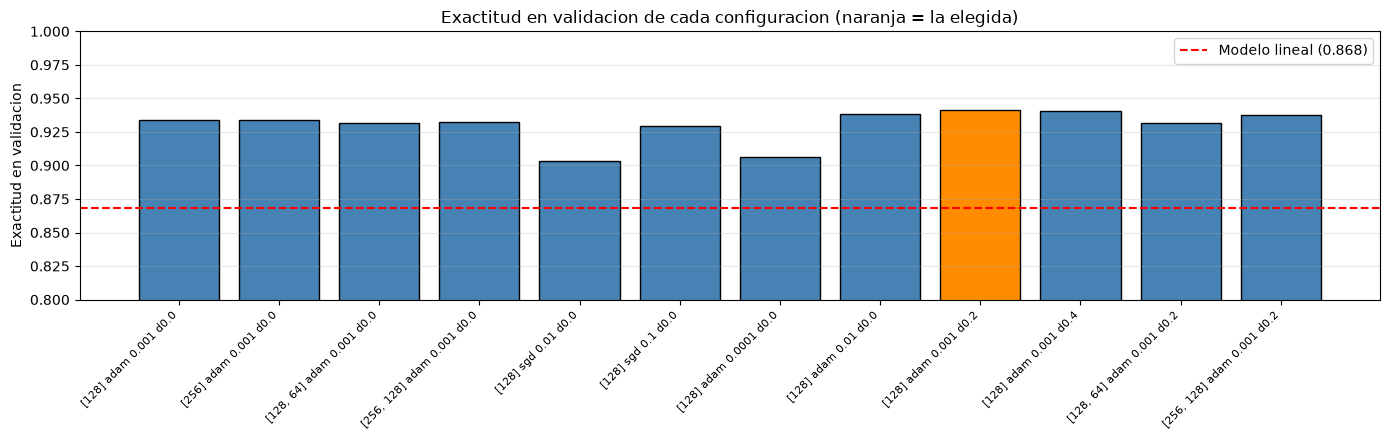

In [13]:
etiquetas_config = [f"{c} {o} {l} d{d}" for c, o, l, d in zip(busqueda['capas ocultas'], busqueda['optimizador'],
                                                               busqueda['lr'], busqueda['dropout'])]
colores = ['darkorange' if i == busqueda['exactitud val'].idxmax() else 'steelblue' for i in busqueda.index]
plt.figure(figsize=(14, 4.5))
plt.bar(range(len(busqueda)), busqueda['exactitud val'], color=colores, edgecolor='black')
plt.axhline(val_lineal, color='red', linestyle='--', label=f'Modelo lineal ({val_lineal:.3f})')
plt.xticks(range(len(busqueda)), etiquetas_config, rotation=45, ha='right', fontsize=8)
plt.ylim(0.8, 1.0)
plt.ylabel('Exactitud en validacion')
plt.title('Exactitud en validacion de cada configuracion (naranja = la elegida)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Todas las redes neuronales le ganan al modelo lineal (86.8% en validacion); la peor tiene 90.3%.
- Mas capas o mas neuronas no ayudaron: con 1 capa de 128 sale 93.4% y con 2 capas de 256 y 128 sale 93.2%. Por eso me quedo con la mas simple.
- SGD con lr 0.01 y Adam con lr 0.0001 aprenden muy lento y en 80 epocas se quedan cerca del 90%. Con Adam y lr 0.001 o 0.01 llega mejor.
- El dropout ayudo un poco: con 0.2 sube de 93.4% a 94.1% en validacion.

La configuracion elegida es 1 capa oculta de 128 neuronas con ReLU, dropout de 0.2 y Adam con lr 0.001.

## 9. Entrenamiento de la red final

Epoca   1  costo train 1.1745  costo val 0.8555  exactitud train 0.5777  exactitud val 0.7476


Epoca  10  costo train 0.2284  costo val 0.2748  exactitud train 0.9290  exactitud val 0.9084


Epoca  20  costo train 0.1443  costo val 0.2274  exactitud train 0.9501  exactitud val 0.9244


Epoca  30  costo train 0.0929  costo val 0.2055  exactitud train 0.9705  exactitud val 0.9342


Epoca  40  costo train 0.0758  costo val 0.1940  exactitud train 0.9764  exactitud val 0.9378


Epoca  50  costo train 0.0622  costo val 0.2103  exactitud train 0.9796  exactitud val 0.9378


Epoca  60  costo train 0.0483  costo val 0.2100  exactitud train 0.9848  exactitud val 0.9396


Epoca  70  costo train 0.0398  costo val 0.2274  exactitud train 0.9899  exactitud val 0.9333


Epoca  80  costo train 0.0343  costo val 0.2276  exactitud train 0.9907  exactitud val 0.9333

RedNeuronal(
  (red): Sequential(
    (0): Linear(in_features=80, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)
Parametros entrenables: 11013
Mejor epoca: 56  (exactitud en validacion 0.9413)


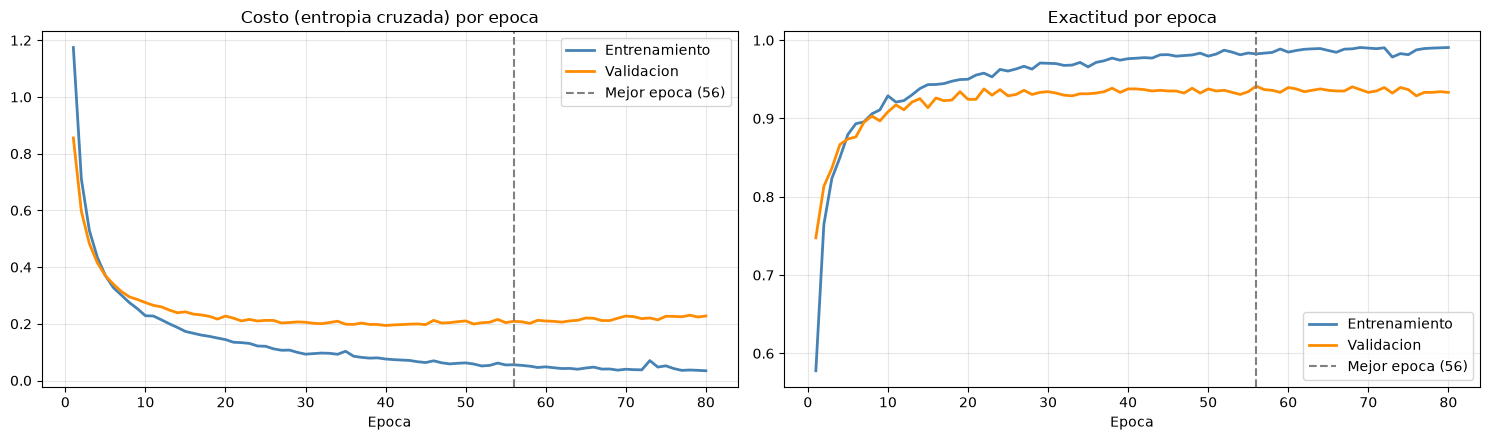

In [14]:
red, historial, mejor_epoca, mejor_val = entrenar(CAPAS, datos_ruido, optimizador=OPTIMIZADOR, lr=LR, dropout=DROPOUT,
                                                  epocas=80, nombre='red_final', mostrar=True)
print()
print(red)
print('Parametros entrenables:', sum(p.numel() for p in red.parameters()))
print(f'Mejor epoca: {mejor_epoca}  (exactitud en validacion {mejor_val:.4f})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))
epocas = range(1, len(historial['costo_train']) + 1)
ax1.plot(epocas, historial['costo_train'], color='steelblue', linewidth=2, label='Entrenamiento')
ax1.plot(epocas, historial['costo_val'], color='darkorange', linewidth=2, label='Validacion')
ax1.set_title('Costo (entropia cruzada) por epoca')
ax2.plot(epocas, historial['exac_train'], color='steelblue', linewidth=2, label='Entrenamiento')
ax2.plot(epocas, historial['exac_val'], color='darkorange', linewidth=2, label='Validacion')
ax2.set_title('Exactitud por epoca')
for ax in (ax1, ax2):
    ax.axvline(mejor_epoca, color='gray', linestyle='--', label=f'Mejor epoca ({mejor_epoca})')
    ax.set_xlabel('Epoca')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La red tiene 11013 parametros entre pesos y sesgos. En las curvas se ve que al principio el costo baja rapido en los dos conjuntos. Desde la epoca 20 o 30 el costo de validacion ya no baja y al final sube un poco, mientras que el de entrenamiento sigue bajando: ahi la red empieza a aprenderse de memoria los datos de entrenamiento (sobreajuste). Por eso me quedo con los pesos de la epoca 56, que es la de mejor exactitud en validacion (94.1%), y no con los de la ultima.

## 10. Evaluacion con los datos de prueba

In [15]:
def metricas(y_real, y_pred, k=5):
    matriz = np.zeros((k, k), dtype=int)
    for a, b in zip(y_real, y_pred):
        matriz[a, b] += 1
    precision = [matriz[i, i] / matriz[:, i].sum() if matriz[:, i].sum() > 0 else 0.0 for i in range(k)]
    sensibilidad = [matriz[i, i] / matriz[i, :].sum() for i in range(k)]
    f1 = [2 * p * s / (p + s) if p + s > 0 else 0.0 for p, s in zip(precision, sensibilidad)]
    return matriz, np.array(precision), np.array(sensibilidad), np.array(f1)


pred_red, prob_red = predecir(red, Xr_te)
pred_tr_red, _ = predecir(red, Xr_tr)
matriz_red, prec_red, sens_red, f1_red = metricas(y_test, pred_red)
matriz_lin, prec_lin, sens_lin, f1_lin = metricas(y_test, pred_lineal)

print(f'Red neuronal  ->  exactitud train {np.mean(pred_tr_red == y_train):.4f}  |  prueba {np.mean(pred_red == y_test):.4f}  |  F1 promedio {f1_red.mean():.4f}')
print(f'Modelo lineal ->  exactitud train {np.mean(pred_tr_lin == y_train):.4f}  |  prueba {np.mean(pred_lineal == y_test):.4f}  |  F1 promedio {f1_lin.mean():.4f}')
pd.DataFrame({'persona': NOMBRES, 'precision': prec_red, 'sensibilidad': sens_red, 'F1 red': f1_red,
              'F1 lineal': f1_lin}).set_index('persona').round(4)

Red neuronal  ->  exactitud train 0.9981  |  prueba 0.9413  |  F1 promedio 0.9414
Modelo lineal ->  exactitud train 0.8844  |  prueba 0.8578  |  F1 promedio 0.8590


,precision,sensibilidad,F1 red,F1 lineal
persona,,,,
Benjamin Netanyahu,0.9140,0.8978,0.9058,0.8251
Jens Stoltenberg,0.9052,0.9333,0.9190,0.8160
Julia Gillard,0.9422,0.9422,0.9422,0.8529
Margaret Thatcher,0.9598,0.9556,0.9577,0.8644
Nelson Mandela,0.9865,0.9778,0.9821,0.9365


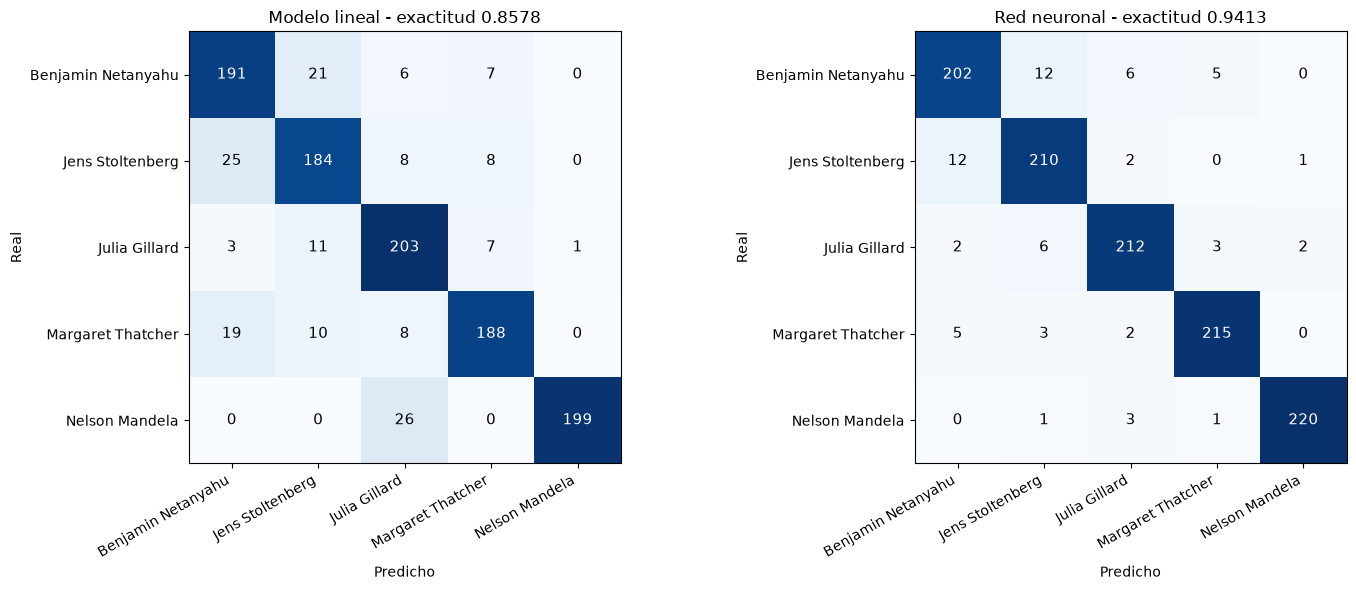

In [16]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 6))
for ax, matriz, titulo in [(ejes[0], matriz_lin, 'Modelo lineal'), (ejes[1], matriz_red, 'Red neuronal')]:
    ax.imshow(matriz, cmap='Blues')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, matriz[i, j], ha='center', va='center', fontsize=11,
                    color='white' if matriz[i, j] > matriz.max() / 2 else 'black')
    ax.set_xticks(range(5))
    ax.set_xticklabels(NOMBRES, rotation=30, ha='right')
    ax.set_yticks(range(5))
    ax.set_yticklabels(NOMBRES)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(f'{titulo} - exactitud {np.trace(matriz) / matriz.sum():.4f}')
plt.tight_layout()
plt.show()

En prueba la red acierta el 94.1% y el modelo lineal el 85.8%, o sea casi 9 puntos mas. El F1 promedio tambien sube de 0.86 a 0.94, y la red es mejor con las 5 personas.

En la matriz de confusion se ve donde se equivoca: la red confunde sobre todo a Benjamin Netanyahu con Jens Stoltenberg (12 veces para cada lado). El modelo lineal ademas confundia a Nelson Mandela con Julia Gillard (26 veces) y a Margaret Thatcher con Netanyahu (19 veces), y eso la red casi lo corrigio. Nelson Mandela es el mas facil de reconocer (F1 de 0.98).

En entrenamiento la red da 99.8% y en prueba 94.1%, entonces hay algo de sobreajuste, pero igual funciona mucho mejor que el modelo lineal con audios que no vio.

### Resultado segun el tipo de ruido y con audio limpio

In [17]:
filas = []
ruido_test = tipo_ruido[idx_test]
for r, nombre in enumerate(NOMBRES_RUIDO):
    s = ruido_test == r
    filas.append({'ruido': nombre, 'audios de prueba': int(s.sum()),
                  'exactitud lineal': np.mean(pred_lineal[s] == y_test[s]),
                  'exactitud red': np.mean(pred_red[s] == y_test[s])})
display(pd.DataFrame(filas).set_index('ruido').round(4))

pred_limpio, _ = predecir(red, (X_limpio[idx_test] - mu_r) / sigma_r)
print(f'La red entrenada con ruido, probada con los mismos audios de prueba SIN ruido: {np.mean(pred_limpio == y_test):.4f}')

,audios de prueba,exactitud lineal,exactitud red
ruido,,,
aplausos,185,0.9189,0.9838
lavar platos,191,0.8325,0.9215
gato,199,0.8492,0.9296
grifo,173,0.8266,0.9480
bicicleta,194,0.8454,0.9227
ruido rosa,183,0.8743,0.9454


La red entrenada con ruido, probada con los mismos audios de prueba SIN ruido: 0.9467


La red le gana al modelo lineal con los 6 tipos de ruido. El ruido que menos molesta son los aplausos (98.4%) y los que mas molestan son lavar platos y la bicicleta (cerca de 92%).

Con los mismos audios de prueba pero sin ruido la red acierta el 94.7%, parecido a lo que saca con ruido. Esto pasa porque la entrene solo con audios con ruido; si se quisiera usar con audio limpio convendria entrenarla con los dos tipos de audio.

## 11. Comprobacion del checkpoint y ejemplos de prediccion

Creo una red nueva sin entrenar, le cargo los pesos guardados en el checkpoint y reviso que prediga exactamente lo mismo. Despues muestro las probabilidades que da la red para algunos audios de prueba.

In [18]:
checkpoint = torch.load(os.path.join('pesos', 'red_final.pt'), map_location=dispositivo)
red_cargada = RedNeuronal(80, CAPAS, 5, DROPOUT).to(dispositivo)
pred_sin_entrenar, _ = predecir(red_cargada, Xr_te)
red_cargada.load_state_dict(checkpoint['estado_modelo'])
pred_cargada, prob_cargada = predecir(red_cargada, Xr_te)
print(f'Red nueva sin entrenar: exactitud {np.mean(pred_sin_entrenar == y_test):.4f}')
print(f'Con el checkpoint (epoca {checkpoint["epoca"]}): exactitud {np.mean(pred_cargada == y_test):.4f}')
print('Mismas probabilidades que la red original:', bool(np.allclose(prob_cargada, prob_red, atol=1e-6)))

elegidos = np.random.RandomState(7).choice(len(idx_test), 8, replace=False)
filas = []
for i in elegidos:
    fila = {'audio': f'{HABLANTES[y_test[i]]}/{numero[idx_test[i]]}.wav', 'ruido': NOMBRES_RUIDO[ruido_test[i]],
            'real': NOMBRES[y_test[i]], 'predicho': NOMBRES[pred_red[i]]}
    for k in range(5):
        fila[NOMBRES[k].split()[-1]] = prob_red[i, k]
    filas.append(fila)
pd.DataFrame(filas).round(3)

Red nueva sin entrenar: exactitud 0.2693
Con el checkpoint (epoca 56): exactitud 0.9413
Mismas probabilidades que la red original: True


,audio,ruido,real,predicho,Netanyahu,Stoltenberg,Gillard,Thatcher,Mandela
0,Benjamin_Netanyau/1328.wav,aplausos,Benjamin Netanyahu,Benjamin Netanyahu,0.998,0.000,0.000,0.001,0.000
1,Nelson_Mandela/1487.wav,gato,Nelson Mandela,Nelson Mandela,0.000,0.000,0.000,0.000,1.000
2,Benjamin_Netanyau/1383.wav,grifo,Benjamin Netanyahu,Benjamin Netanyahu,0.977,0.020,0.000,0.003,0.000
3,Julia_Gillard/1460.wav,bicicleta,Julia Gillard,Julia Gillard,0.000,0.000,1.000,0.000,0.000
4,Jens_Stoltenberg/1410.wav,bicicleta,Jens Stoltenberg,Nelson Mandela,0.000,0.215,0.024,0.000,0.762
5,Benjamin_Netanyau/1416.wav,aplausos,Benjamin Netanyahu,Benjamin Netanyahu,0.992,0.007,0.000,0.000,0.000
6,Nelson_Mandela/1499.wav,gato,Nelson Mandela,Nelson Mandela,0.000,0.070,0.074,0.000,0.856
7,Julia_Gillard/1496.wav,ruido rosa,Julia Gillard,Julia Gillard,0.000,0.000,0.999,0.001,0.000


## 12. Conclusiones

- Con audio limpio reconocer a estas 5 personas es facil: hasta el modelo lineal de los labs llega a 99.5%.
- Con ruido de fondo, que es el caso real, el modelo lineal baja a 85.8% y la red neuronal con una capa oculta de 128 neuronas llega a 94.1% en prueba. La capa oculta con ReLU le permite separar clases que un modelo lineal no puede.
- Lo que mas ayudo a la red fue usar Adam con una buena tasa de aprendizaje y un poco de dropout. Poner mas capas no mejoro.
- La validacion sirvio para elegir la configuracion y la mejor epoca sin tocar la prueba, y asi no quedarme con una red sobreajustada.
- Lo que mas le cuesta es diferenciar a Netanyahu de Stoltenberg. Para mejorar se podria entrenar con mas tipos de ruido o juntar audios limpios y con ruido.